# Example: Static PSBL and BSBL Geometry Plots

`plot_PSBL_static` and `plot_BSBL_static` (in `bagle.plot_models`) draw a
still-frame view of a binary-lens event:

* full astrometric trajectories over a time window centered on $t_0$
* snapshot markers at $t_0$ (lenses, unlensed source(s), lensed images)
* the light curve with a vertical line at $t_0$

The right-hand text panel lists model parameters and is titled with the
concrete class name (`type(model).__name__`). These functions are the
static counterparts of `plot_PSBL` and `plot_BSBL` (the latter writes an
animation).

This notebook builds two photometry+astrometry models that include
**both Keplerian orbital motion and parallax**, then calls the static
plotters. A nearby lens ($d_L = 300$ pc) and a bulge source
($d_S = 8$ kpc) make the parallax wobble large; a few-AU projected
orbit makes the lens (and, for BSBL, source) tracks curve over a few
$t_E$.


In [1]:
%matplotlib inline
import numpy as np
from bagle import model
from bagle import plot_models

## PSBL with parallax and elliptical orbits

Use `PSBL_PhotAstrom_Par_EllOrbs_Param1`. The projected semi-major
axis $a = 5$ mas at $d_L = 300$ pc is about 1.5 AU, so the binary lens
completes a substantial fraction of an orbit over a few Einstein
crossing times.

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.5 | $M_\odot$ |
| $t_{0,\mathrm{com}}$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta_{\mathrm{com}}$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 5.0, 2.0 | mas/yr |
| $\omega_{\mathrm{pri}}$, $\Omega_{\mathrm{sec}}$ | 90, 20 | deg |
| $i$, $e$ | 55, 0.35 | deg, — |
| $t_p$, $a$ | 57000, 5.0 | MJD, mas |
| $\mu_{S,E}$, $\mu_{S,N}$ | −1.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 300, 8000 | pc |
| $b_{sff}$, mag$_S$ | 1.0, 18.0 | — |
| $\Delta m_{L_p,L_s}$ | 0.0 | mag |
| R.A., Dec. | 259.5, −29.0 | deg |


In [2]:
# Nearby lens + bulge source so parallax wobble is visible.
mLp = 0.8
mLs = 0.5
t0_com = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta_com = 1.5
muL_E = 5.0
muL_N = 2.0
muS_E = -1.0
muS_N = 3.0
omega_pri = 90.0
big_omega_sec = 20.0
i = 55.0
e = 0.35
tp = 57000.0
a = 5.0
dL = 300.0
dS = 8000.0
b_sff = np.array([1.0])
mag_src = np.array([18.0])
dmag_Lp_Ls = np.array([0.0])
raL = 259.5
decL = -29.0

psbl = model.PSBL_PhotAstrom_Par_EllOrbs_Param1(
    mLp, mLs, t0_com, xS0_E, xS0_N,
    beta_com, muL_E, muL_N,
    omega_pri, big_omega_sec, i, e, tp, a,
    muS_E, muS_N, dL, dS,
    b_sff, mag_src, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(psbl).__name__)
print('tE = {:.1f} days'.format(psbl.tE))
print('thetaE = {:.2f} mas'.format(psbl.thetaE_amp))
print('piE_amp = {:.2f}'.format(psbl.piE_amp))

class: PSBL_PhotAstrom_Par_EllOrbs_Param1
tE = 350.0 days
thetaE = 5.83 mas
piE_amp = 0.55


`duration` is in units of $t_E$ and is centered on $t_0$. Use
`time_steps=500` over 8 $t_E$ so the curved lens tracks and parallax
wobble are well sampled.


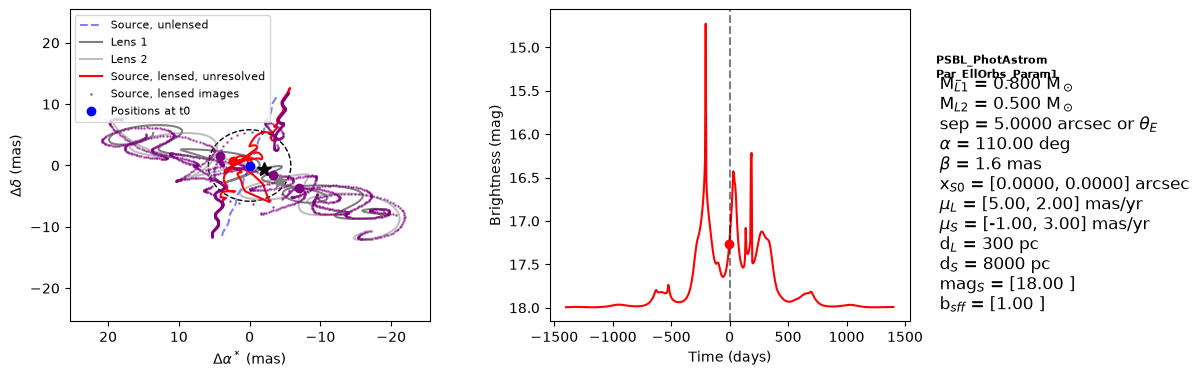

In [3]:
# Static geometry: full tracks plus t0 markers.
# The plotter always writes a PNG; the figure also displays inline.
plot_models.plot_PSBL_static(
    psbl, duration=8, time_steps=500,
    outfile='/tmp/psbl_par_ellorbs_static.png',
)

## BSBL with parallax and elliptical orbits

Use `BSBL_PhotAstrom_Par_EllOrbs_Param1`. Both the binary lens and the
binary source have Keplerian orbits. The second source and its images
are drawn in cyan / hotpink so they stay distinct from the primary.

| Param | Value | units |
|-------|-------|-------|
| $m_{L,p}$, $m_{L,s}$ | 0.8, 0.4 | $M_\odot$ |
| $t_{0,\mathrm{com}}$ | 57000 | MJD |
| $x_{S0,E}$, $x_{S0,N}$ | 0.0, 0.0 | arcsec |
| $\beta$ | 1.5 | mas |
| $\mu_{L,E}$, $\mu_{L,N}$ | 4.0, 1.0 | mas/yr |
| $\mu_{S,E}$, $\mu_{S,N}$ | −2.0, 3.0 | mas/yr |
| $d_L$, $d_S$ | 300, 8000 | pc |
| $\omega_{L,\mathrm{pri}}$, $\Omega_{L,\mathrm{sec}}$ | 90, 20 | deg |
| $i_L$, $e_L$ | 55, 0.35 | deg, — |
| $t_{p,L}$, $a_L$ | 57000, 5.0 | MJD, mas |
| $\omega_{S,\mathrm{pri}}$, $\Omega_{S,\mathrm{sec}}$ | 0, 90 | deg |
| $i_S$, $e_S$, $P_S$ | 50, 0.25, 500 | deg, —, days |
| $t_{p,S}$, $\aleph_S$, $\aleph_{S,\mathrm{sec}}$ | 57000, 1.5, 2.0 | MJD, mas, mas |
| mag$_{S,\mathrm{pri}}$, mag$_{S,\mathrm{sec}}$ | 18.0, 19.0 | mag |
| $b_{sff}$, $\Delta m_{L_p,L_s}$ | 1.0, 20.0 | —, mag |
| R.A., Dec. | 259.5, −29.0 | deg |


In [4]:
# Nearby lens + bulge source; lens and source both Keplerian.
mLp = 0.8
mLs = 0.4
t0_com = 57000.0
xS0_E = 0.0
xS0_N = 0.0
beta = 1.5
muL_E = 4.0
muL_N = 1.0
muS_E = -2.0
muS_N = 3.0
dL = 300.0
dS = 8000.0
omegaL_pri = 90.0
big_omegaL_sec = 20.0
iL = 55.0
eL = 0.35
tpL = 57000.0
aL = 5.0
omegaS_pri = 0.0
big_omegaS_sec = 90.0
iS = 50.0
eS = 0.25
pS = 500.0
tpS = 57000.0
alephS = 1.5
aleph_secS = 2.0
mag_src_pri = 18.0
mag_src_sec = 19.0
b_sff = np.array([1.0])
dmag_Lp_Ls = np.array([20.0])
raL = 259.5
decL = -29.0

bsbl = model.BSBL_PhotAstrom_Par_EllOrbs_Param1(
    mLp, mLs, t0_com, xS0_E, xS0_N,
    beta, muL_E, muL_N, muS_E, muS_N, dL, dS,
    omegaL_pri, big_omegaL_sec, iL, eL, tpL, aL,
    omegaS_pri, big_omegaS_sec, iS, eS, pS, tpS,
    alephS, aleph_secS,
    mag_src_pri, mag_src_sec, b_sff, dmag_Lp_Ls,
    raL=raL, decL=decL, root_tol=1e-8,
)

print('class:', type(bsbl).__name__)
print('tE = {:.1f} days'.format(bsbl.tE))
print('thetaE = {:.2f} mas'.format(bsbl.thetaE_amp))
print('piE_amp = {:.2f}'.format(bsbl.piE_amp))

class: BSBL_PhotAstrom_Par_EllOrbs_Param1
tE = 323.4 days
thetaE = 5.60 mas
piE_amp = 0.57


Same time window as the PSBL example. `plot_BSBL_static` marks both
sources and both lenses at $t_0$.


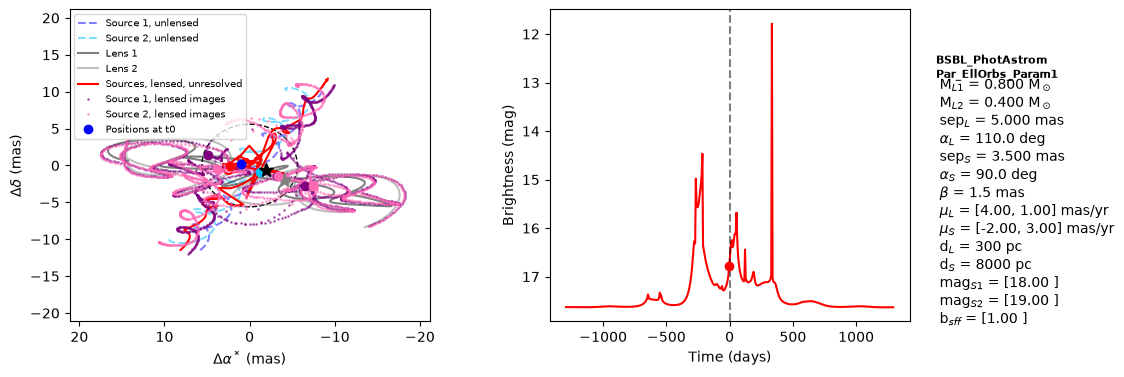

In [5]:
# Static geometry for the binary-source binary-lens event.
plot_models.plot_BSBL_static(
    bsbl, duration=8, time_steps=500,
    outfile='/tmp/bsbl_par_ellorbs_static.png',
)